<a href="https://colab.research.google.com/github/Abhishek0716ss/MachineLearning-2025/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
clusters[:10]


array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2], dtype=int32)

In [5]:
comparison = pd.DataFrame({
    "Actual": y,
    "Cluster": clusters
})

comparison.head(10)


,Actual,Cluster
0,0,1
1,0,2
2,0,2
3,0,2
4,0,1
5,0,1
6,0,1
7,0,1
8,0,2
9,0,2


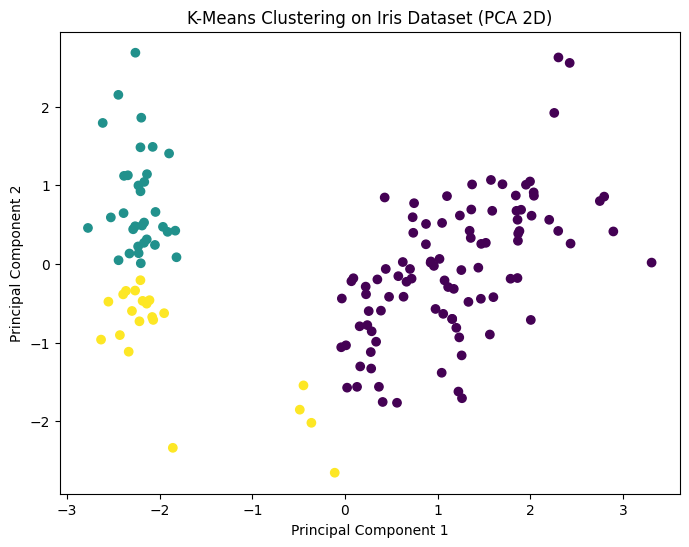

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("K-Means Clustering on Iris Dataset (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


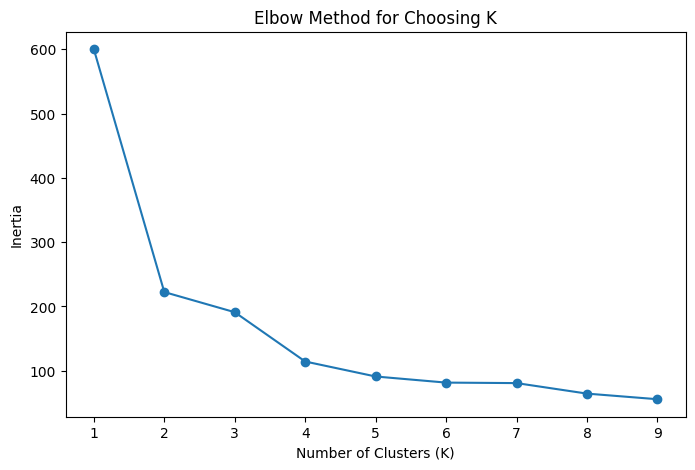

In [12]:
inertia_list = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 10), inertia_list, marker='o')
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


Centroid based k means clustering

In [8]:
#Centroid based k means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
centroids = kmeans.cluster_centers_



In [9]:
print("Cluster Centroids (in scaled feature space):")
print(centroids)


Cluster Centroids (in scaled feature space):
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


In [10]:
df['Cluster'] = clusters
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


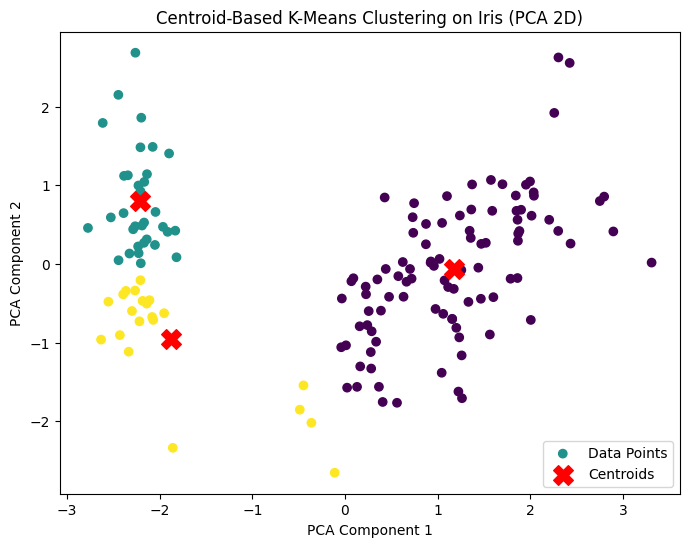

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids to the same PCA space
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', label='Data Points')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            color='red', s=200, marker='X', label='Centroids')
plt.title("Centroid-Based K-Means Clustering on Iris (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


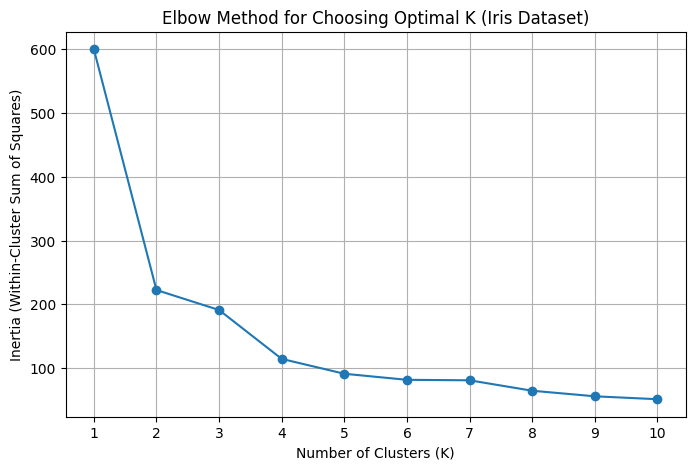

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Use the scaled data (X_scaled) from previous steps
inertia_list = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method for Choosing Optimal K (Iris Dataset)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(K_range)
plt.grid(True)
plt.show()
